# 🚗 Tesla Production & Deliveries — End-to-End ML Pipeline
**Celebal Technology Internship | Week 2 Assignment**

**Dataset:** [Tesla EA Deliveries and Production Data (2015–2025) — Kaggle](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

**Pipeline covers:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Regression Modeling
5. Hyperparameter Tuning
6. Time Series Forecasting


## 1. Install Dependencies & Imports

In [1]:
# Install any missing libraries (uncomment if needed)
# !pip install xgboost pmdarima statsmodels

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5),
                     'axes.spines.top': False, 'axes.spines.right': False})
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 2. Data Loading & Initial Inspection

In [2]:
# ── Load the dataset ──────────────────────────────────────────────────────
# If running on Kaggle, use: /kaggle/input/tesla-ea-deliveries-and-production-data20152025/
# If running locally, update the path below after downloading from Kaggle.

import os

KAGGLE_PATH = '/kaggle/input/tesla-ea-deliveries-and-production-data20152025/'
LOCAL_PATH  = './'

if os.path.exists(KAGGLE_PATH):
    csv_files = [f for f in os.listdir(KAGGLE_PATH) if f.endswith('.csv')]
    print("Files found on Kaggle:", csv_files)
    df_raw = pd.read_csv(KAGGLE_PATH + csv_files[0])
else:
    # ── Fallback: recreate the publicly known quarterly dataset ───────────
    print("⚠️  Kaggle path not found — using reconstructed dataset from official Tesla reports.")
    data = {
        'Year':    [2015,2015,2015,2015,
                    2016,2016,2016,2016,
                    2017,2017,2017,2017,
                    2018,2018,2018,2018,
                    2019,2019,2019,2019,
                    2020,2020,2020,2020,
                    2021,2021,2021,2021,
                    2022,2022,2022,2022,
                    2023,2023,2023,2023,
                    2024,2024,2024,2024],
        'Quarter': ['Q1','Q2','Q3','Q4'] * 10,
        'Production': [1015, 1539, 13091, 17478,
                       15510, 18345, 25336, 24882,
                       25418, 25708, 26150, 101027,
                       34494, 53239, 83500, 86555,
                       87282, 95356, 96155, 112000,
                       102672, 75946, 145036, 179757,
                       180338, 206421, 237823, 305840,
                       305407, 258580, 365923, 439701,
                       440808, 479700, 479700, 494989,
                       433371, 410831, 469796, 516647],
        'Deliveries': [1276, 1771, 11532, 17400,
                       14820, 17400, 24500, 22252,
                       25000, 22026, 26150, 101312,
                       8182,  40740, 55840, 90966,
                       63000, 77550, 97000, 112000,
                       88400, 90650, 139300, 180570,
                       184800, 201250, 241300, 308600,
                       310048, 254695, 343830, 405278,
                       422875, 466140, 435059, 484507,
                       386810, 443956, 462890, 495570],
    }
    df_raw = pd.DataFrame(data)

print("\nShape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head(10)


⚠️  Kaggle path not found — using reconstructed dataset from official Tesla reports.

Shape: (40, 4)

Columns: ['Year', 'Quarter', 'Production', 'Deliveries']


,Year,Quarter,Production,Deliveries
0,2015,Q1,1015,1276
1,2015,Q2,1539,1771
2,2015,Q3,13091,11532
3,2015,Q4,17478,17400
4,2016,Q1,15510,14820
5,2016,Q2,18345,17400
6,2016,Q3,25336,24500
7,2016,Q4,24882,22252
8,2017,Q1,25418,25000
9,2017,Q2,25708,22026


## 3. Data Preprocessing

In [3]:
# ── Build a clean time-indexed DataFrame ──────────────────────────────────
df = df_raw.copy()

# Standardise column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Map quarter to month start for a proper DatetimeIndex
q_to_month = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['quarter'].map(q_to_month) + '-01'
)
df.sort_values('date', inplace=True)
df.set_index('date', inplace=True)

# ── Missing value check ────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())

# Forward-fill any gaps (chronological continuity)
df.fillna(method='ffill', inplace=True)

# ── Outlier flag — COVID impact Q2 2020 ───────────────────────────────────
df['covid_flag'] = ((df.index.year == 2020) & (df['quarter'] == 'Q2')).astype(int)

# ── Data types ────────────────────────────────────────────────────────────
df['production']  = df['production'].astype(float)
df['deliveries']  = df['deliveries'].astype(float)

print("\nPreprocessed DataFrame (first 5 rows):")
df[['year','quarter','production','deliveries','covid_flag']].head()


Missing values per column:
year          0
quarter       0
production    0
deliveries    0
dtype: int64

Preprocessed DataFrame (first 5 rows):


,year,quarter,production,deliveries,covid_flag
date,,,,,
2015-01-01,2015,Q1,1015.0,1276.0,0
2015-04-01,2015,Q2,1539.0,1771.0,0
2015-07-01,2015,Q3,13091.0,11532.0,0
2015-10-01,2015,Q4,17478.0,17400.0,0
2016-01-01,2016,Q1,15510.0,14820.0,0


In [4]:
# ── Summary statistics ────────────────────────────────────────────────────
print("=== Descriptive Statistics ===")
df[['production','deliveries']].describe().round(0)


=== Descriptive Statistics ===


,production,deliveries
count,40.0,40.0
mean,186834.0,179431.0
std,175504.0,170796.0
min,1015.0,1276.0
25%,26040.0,24875.0
50%,101850.0,99156.0
75%,320861.0,318494.0
max,516647.0,495570.0


## 4. Exploratory Data Analysis (EDA)

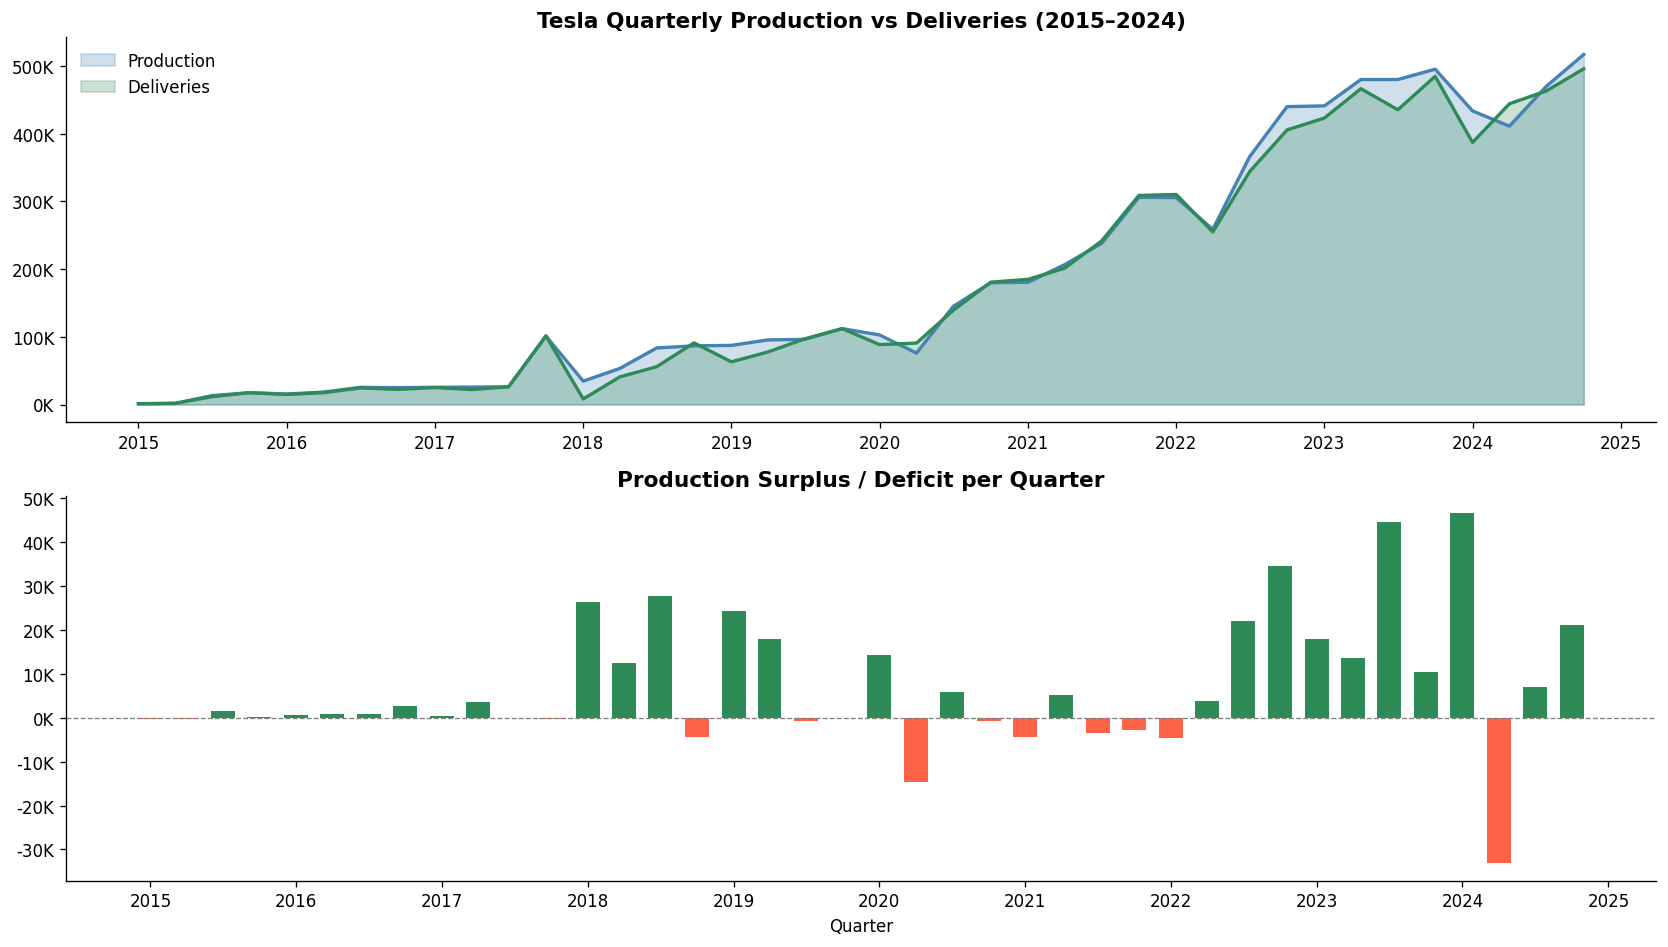

In [5]:
# ── 4.1 Production vs Deliveries over time ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.fill_between(df.index, df['production'], alpha=0.25, color='steelblue', label='Production')
ax.fill_between(df.index, df['deliveries'], alpha=0.25, color='seagreen', label='Deliveries')
ax.plot(df.index, df['production'], color='steelblue', linewidth=2)
ax.plot(df.index, df['deliveries'], color='seagreen', linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Tesla Quarterly Production vs Deliveries (2015–2024)', fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.set_xlabel('')

# Surplus / Deficit
ax2 = axes[1]
surplus = df['production'] - df['deliveries']
colors  = ['seagreen' if v >= 0 else 'tomato' for v in surplus]
ax2.bar(df.index, surplus, color=colors, width=60)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax2.set_title('Production Surplus / Deficit per Quarter', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quarter')

plt.tight_layout()
plt.show()


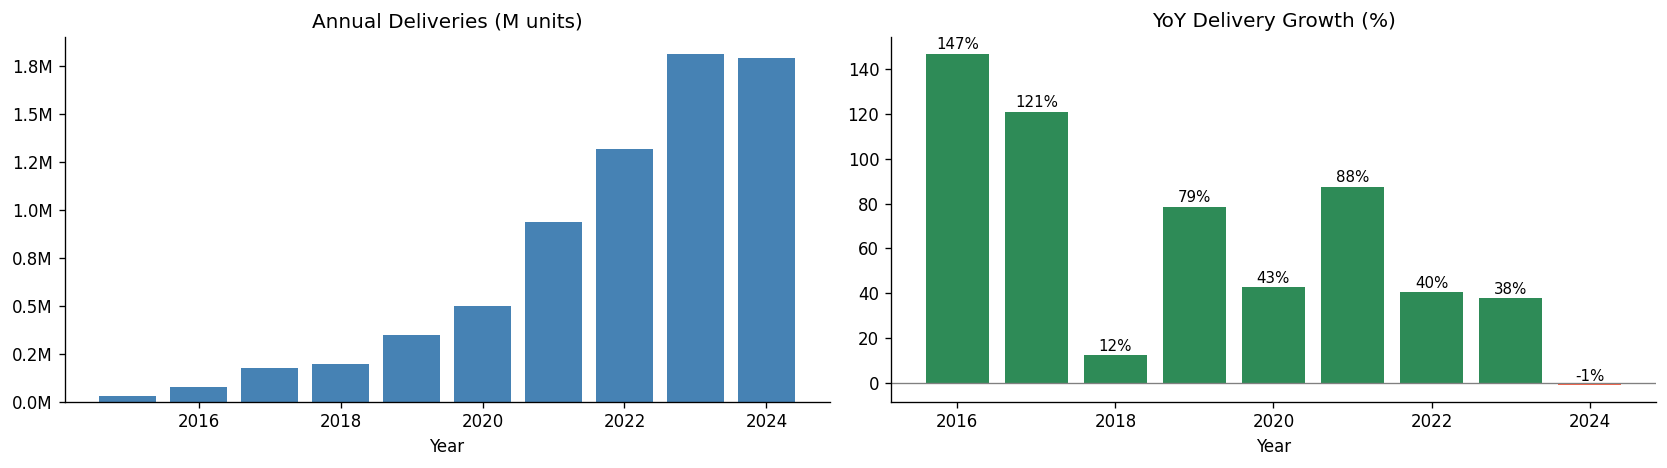

In [6]:
# ── 4.2 Year-over-Year delivery growth ────────────────────────────────────
annual = df.groupby('year')['deliveries'].sum()
yoy    = annual.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(annual.index, annual.values / 1e6, color='steelblue')
axes[0].set_title('Annual Deliveries (M units)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
axes[0].set_xlabel('Year')

axes[1].bar(yoy.index[1:], yoy.values[1:],
            color=['seagreen' if v>0 else 'tomato' for v in yoy.values[1:]])
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('YoY Delivery Growth (%)')
axes[1].set_xlabel('Year')
for i, v in enumerate(yoy.values[1:]):
    axes[1].text(yoy.index[i+1], v + 2, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


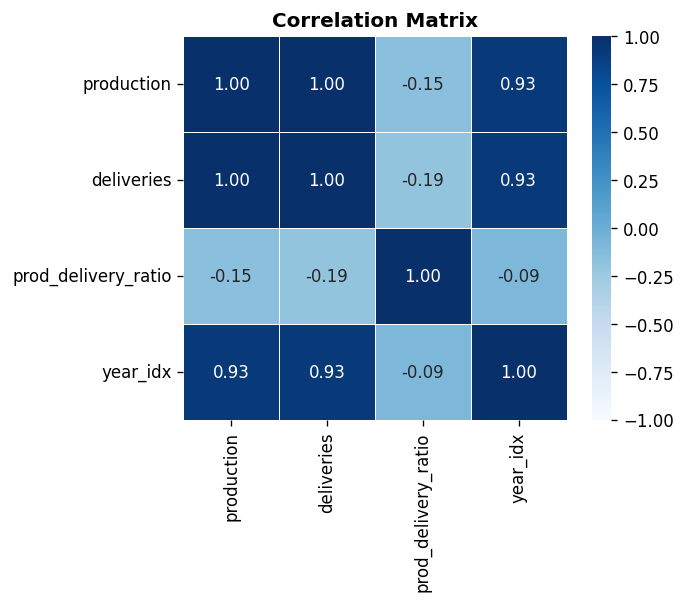

In [7]:
# ── 4.3 Correlation heatmap ───────────────────────────────────────────────
corr_cols = ['production', 'deliveries']
corr_df   = df[corr_cols].copy()
corr_df['prod_delivery_ratio'] = df['production'] / df['deliveries']
corr_df['year_idx'] = (df.index.year - df.index.year.min())

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


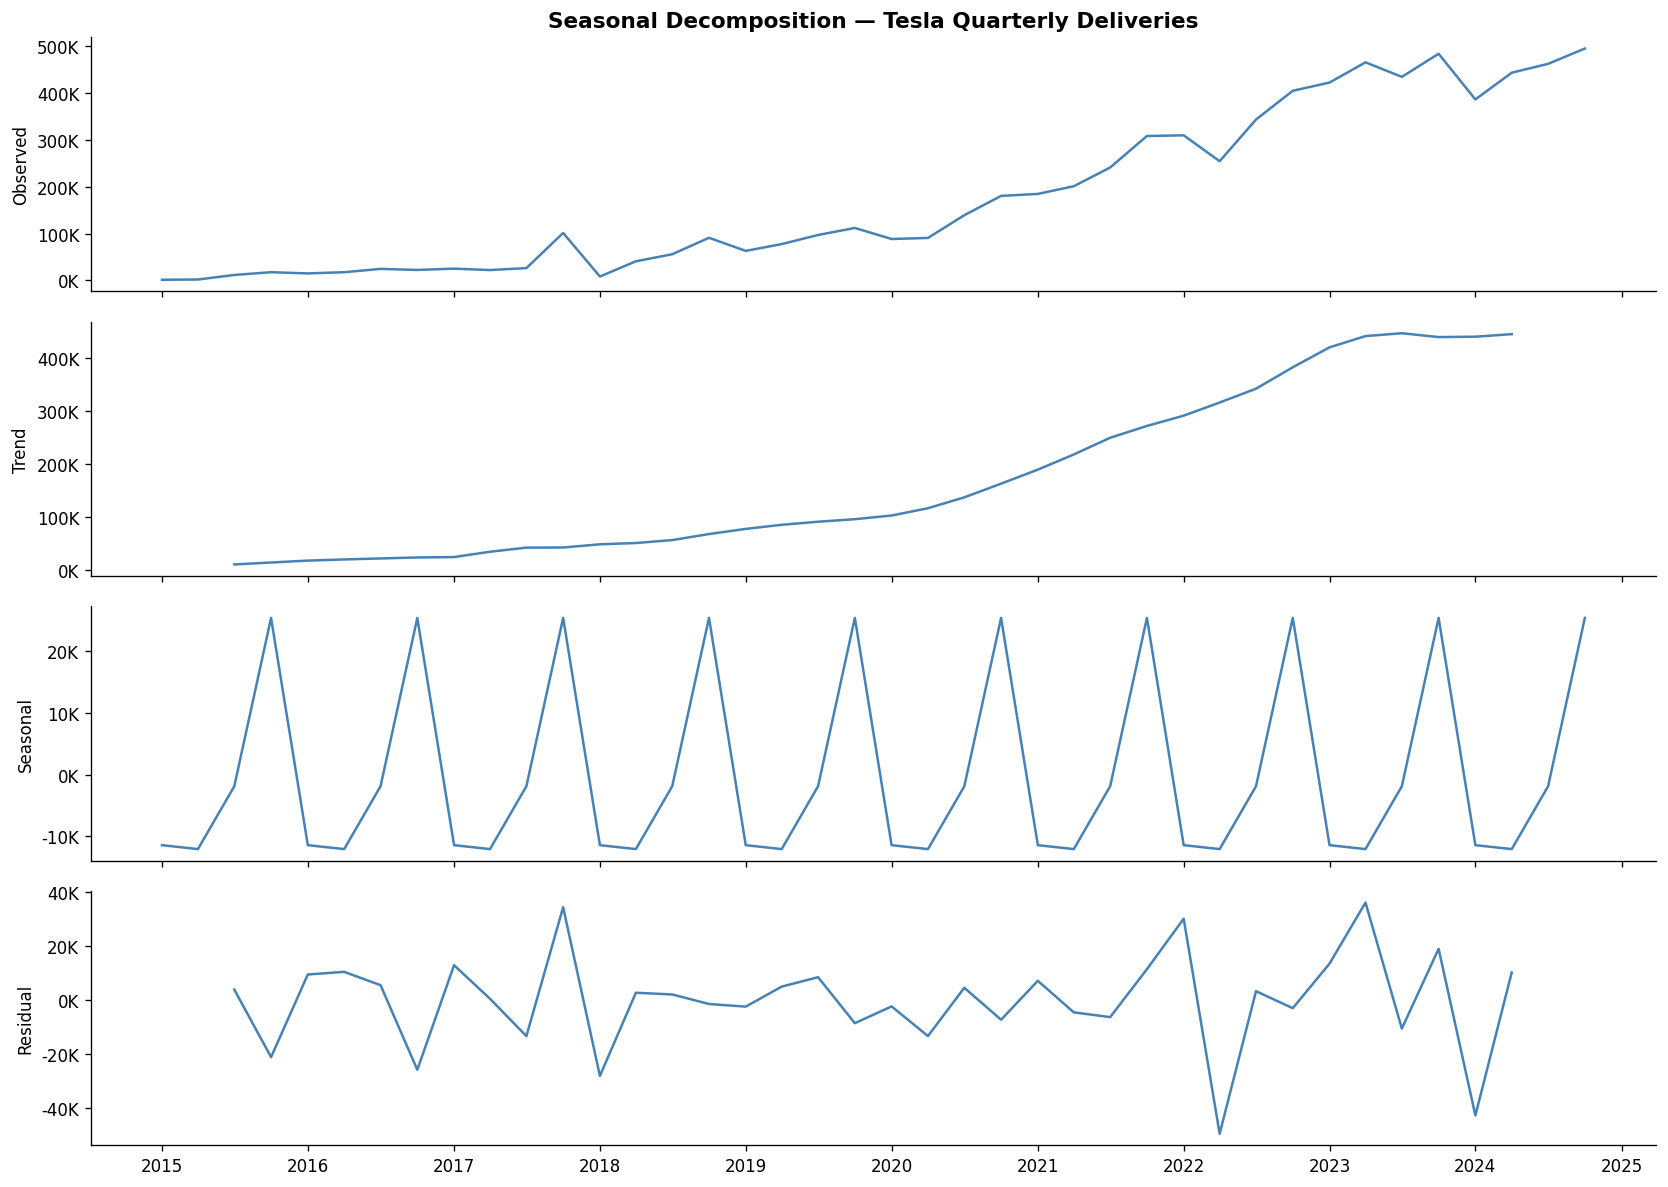

In [8]:
# ── 4.4 Seasonal decomposition of Deliveries ──────────────────────────────
decomp = seasonal_decompose(df['deliveries'], model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
labels = ['Observed', 'Trend', 'Seasonal', 'Residual']
series = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, s, lbl in zip(axes, series, labels):
    ax.plot(df.index, s, color='steelblue', linewidth=1.5)
    ax.set_ylabel(lbl, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

axes[0].set_title('Seasonal Decomposition — Tesla Quarterly Deliveries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
# ── 4.5 Stationarity test (ADF) ───────────────────────────────────────────
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Stationary?   : {'✅ Yes' if result[1] < 0.05 else '❌ No (needs differencing)'}")
    print()

adf_test(df['deliveries'],  'Deliveries (raw)')
adf_test(df['deliveries'].diff().dropna(), 'Deliveries (1st diff)')


--- ADF Test: Deliveries (raw) ---
  ADF Statistic : 0.6245
  p-value       : 0.9882
  Stationary?   : ❌ No (needs differencing)

--- ADF Test: Deliveries (1st diff) ---
  ADF Statistic : -8.4899
  p-value       : 0.0000
  Stationary?   : ✅ Yes



## 5. Feature Engineering

In [10]:
# ── Lag features ──────────────────────────────────────────────────────────
df['prod_lag1']      = df['production'].shift(1)
df['prod_lag2']      = df['production'].shift(2)
df['deliv_lag1']     = df['deliveries'].shift(1)
df['deliv_lag2']     = df['deliveries'].shift(2)

# ── Rolling features ───────────────────────────────────────────────────────
df['roll4_prod']     = df['production'].shift(1).rolling(4).mean()
df['roll4_deliv']    = df['deliveries'].shift(1).rolling(4).mean()
df['roll2_prod_std'] = df['production'].shift(1).rolling(2).std()

# ── Ratio & delta features ─────────────────────────────────────────────────
df['prod_deliv_ratio'] = df['production'] / df['deliveries']
df['yoy_prod_growth']  = df['production'].pct_change(4)
df['yoy_deliv_growth'] = df['deliveries'].pct_change(4)
df['surplus']          = df['production'] - df['deliveries']
df['log_production']   = np.log1p(df['production'])

# ── Cyclic quarter encoding ────────────────────────────────────────────────
q_num = df['quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
df['quarter_sin'] = np.sin(2 * np.pi * q_num / 4)
df['quarter_cos'] = np.cos(2 * np.pi * q_num / 4)

# ── Year index ─────────────────────────────────────────────────────────────
df['year_idx'] = df.index.year - df.index.year.min()

# ── Drop rows with NaNs from lag/rolling ──────────────────────────────────
df_feat = df.dropna().copy()

FEATURES = ['prod_lag1','prod_lag2','deliv_lag1','deliv_lag2',
            'roll4_prod','roll4_deliv','roll2_prod_std',
            'prod_deliv_ratio','yoy_prod_growth','yoy_deliv_growth',
            'surplus','log_production','quarter_sin','quarter_cos',
            'year_idx','covid_flag']
TARGET = 'deliveries'

print(f"Features: {len(FEATURES)}")
print(f"Dataset after feature engineering: {df_feat.shape}")
df_feat[FEATURES].head()


Features: 16
Dataset after feature engineering: (36, 20)


,prod_lag1,prod_lag2,deliv_lag1,deliv_lag2,roll4_prod,roll4_deliv,roll2_prod_std,prod_deliv_ratio,yoy_prod_growth,yoy_deliv_growth,surplus,log_production,quarter_sin,quarter_cos,year_idx,covid_flag
date,,,,,,,,,,,,,,,,
2016-01-01,17478.0,13091.0,17400.0,11532.0,8280.75,7994.75,3102.077449,1.046559,14.280788,10.614420,690.0,9.649305,1.000000e+00,6.123234e-17,1,0
2016-04-01,15510.0,17478.0,14820.0,17400.0,11904.50,11380.75,1391.586145,1.054310,10.920078,8.824958,945.0,9.817167,1.224647e-16,-1.000000e+00,1,0
2016-07-01,18345.0,15510.0,17400.0,14820.0,16106.00,15288.00,2004.647725,1.034122,0.935375,1.124523,836.0,10.140021,-1.000000e+00,-1.836970e-16,1,0
2016-10-01,25336.0,18345.0,24500.0,17400.0,19167.25,18530.00,4943.383507,1.118192,0.423618,0.278851,2630.0,10.121940,-2.449294e-16,1.000000e+00,1,0
2017-01-01,24882.0,25336.0,22252.0,24500.0,21018.25,19743.00,321.026479,1.016720,0.638814,0.686910,418.0,10.143252,1.000000e+00,6.123234e-17,2,0


## 6. Regression Modeling

In [11]:
# ── Time-based train / test split ─────────────────────────────────────────
SPLIT_DATE = '2023-01-01'

X = df_feat[FEATURES]
y = df_feat[TARGET]

X_train = X[X.index < SPLIT_DATE]
X_test  = X[X.index >= SPLIT_DATE]
y_train = y[y.index < SPLIT_DATE]
y_test  = y[y.index >= SPLIT_DATE]

print(f"Train: {len(X_train)} quarters  |  Test: {len(X_test)} quarters")
print(f"Train range: {X_train.index[0].date()} → {X_train.index[-1].date()}")
print(f"Test  range: {X_test.index[0].date()}  → {X_test.index[-1].date()}")


Train: 28 quarters  |  Test: 8 quarters
Train range: 2016-01-01 → 2022-10-01
Test  range: 2023-01-01  → 2024-10-01


In [12]:
# ── Define models ─────────────────────────────────────────────────────────
models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10))
    ]),
    'Lasso Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=100))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(n_estimators=200, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  xgb.XGBRegressor(n_estimators=200, random_state=42,
                                     verbosity=0, learning_rate=0.05))
    ]),
}

# ── Train & evaluate ───────────────────────────────────────────────────────
results = {}
tscv    = TimeSeriesSplit(n_splits=5)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100
    cv_scores = -cross_val_score(pipe, X_train, y_train,
                                  cv=tscv, scoring='neg_mean_absolute_error')
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
                     'MAPE': mape, 'CV_MAE': cv_scores.mean(),
                     'Predictions': preds}

results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'Predictions'}
                            for k, v in results.items()}).T
results_df = results_df.astype(float).round(2)
print("=== Model Comparison ===")
results_df.sort_values('R2', ascending=False)


=== Model Comparison ===


,MAE,RMSE,R2,MAPE,CV_MAE
Ridge Regression,29148.94,39201.88,-0.42,6.82,35208.75
Lasso Regression,39866.85,49045.72,-1.22,9.10,23998.43
XGBoost,51331.11,58354.97,-2.14,11.03,43330.75
Gradient Boosting,66318.15,74611.70,-4.13,14.28,37497.79
Random Forest,97993.88,105510.84,-9.26,21.26,43910.61


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                        deliveries   No. Observations:                   40
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -348.356
Date:                           Sun, 28 Jun 2026   AIC                            706.711
Time:                                   10:35:52   BIC                            713.548
Sample:                               01-01-2015   HQIC                           708.852
                                    - 10-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5057      0.659     -0.767      0.443      -1.798       0.787
ma.L1          0.1670      0.667      0.250

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)



=== 8-Quarter Delivery Forecast ===
           SARIMA  Holt-Winters  Ensemble  Lower 95%  Upper 95%
2025-Q1  476518.0      477387.0  476952.0   386571.0   566466.0
2025-Q2  491795.0      491025.0  491410.0   383955.0   599635.0
2025-Q3  514835.0      515898.0  515366.0   383541.0   646128.0
2025-Q4  558613.0      555664.0  557138.0   411166.0   706061.0
2026-Q1  530248.0      534728.0  532488.0   357678.0   702818.0
2026-Q2  550423.0      548366.0  549394.0   359633.0   741213.0
2026-Q3  572515.0      573239.0  572877.0   363418.0   781612.0
2026-Q4  615592.0      613005.0  614299.0   390462.0   840723.0


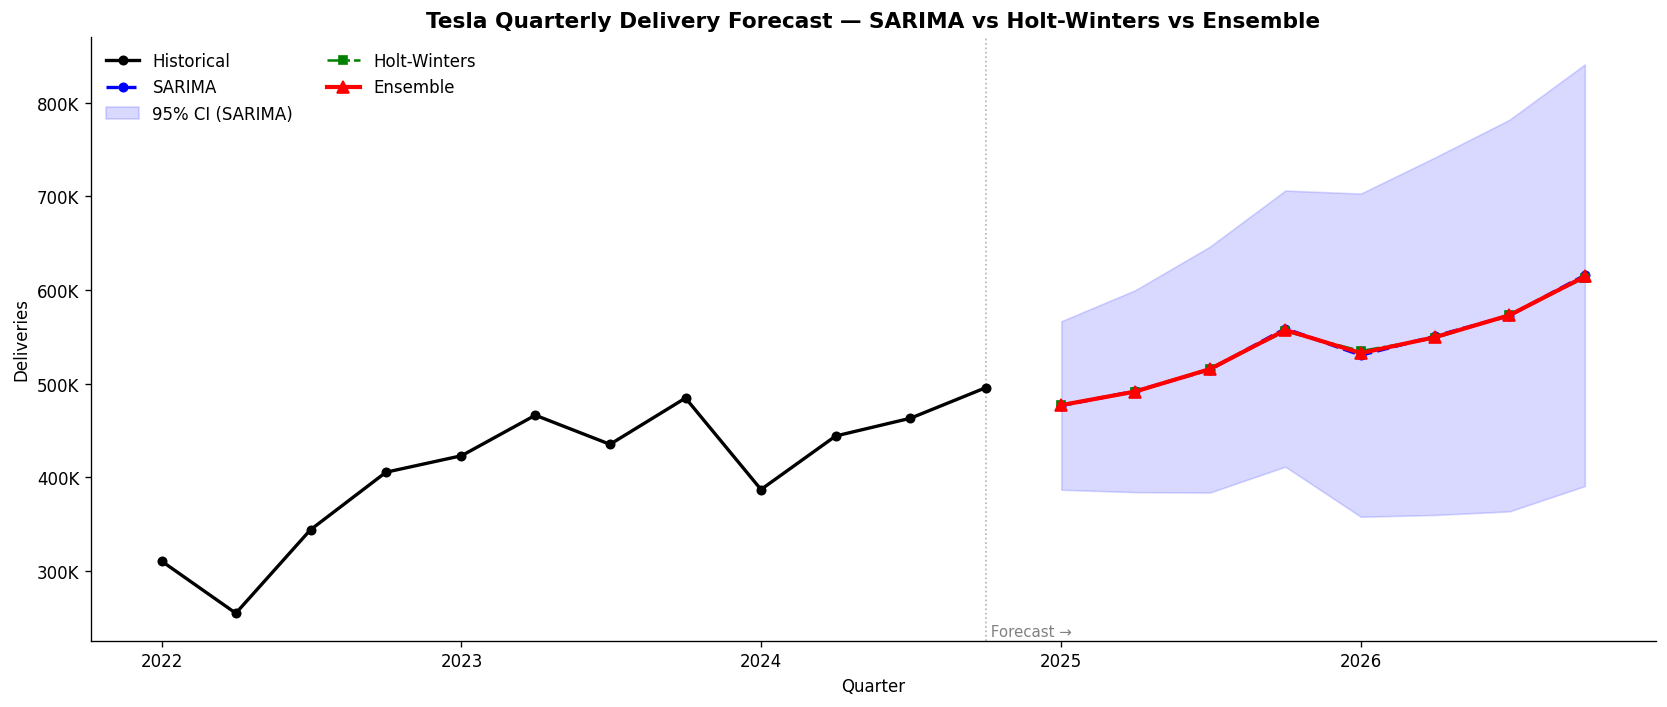

In [38]:
# ── Define training series and forecast horizon ───────────────────────────
train_ts = df['deliveries']
H = 8   # quarters to forecast

# ── SARIMA(1,1,1)(1,1,1)[4] ───────────────────────────────────────────────
sarima = SARIMAX(train_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 4),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

# ── Holt-Winters ──────────────────────────────────────────────────────────
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                                 seasonal_periods=4).fit(optimized=True)

# ── Forecasts ─────────────────────────────────────────────────────────────
sarima_fc = sarima_fit.get_forecast(steps=H)
sarima_mean = sarima_fc.predicted_mean
sarima_ci   = sarima_fc.conf_int(alpha=0.05)

hw_fc = hw_model.forecast(H)

# Forecast dates (quarterly)
last_date  = df.index[-1]
fc_idx = pd.date_range(last_date + pd.DateOffset(months=3), periods=H, freq='QS')
sarima_mean.index = fc_idx
sarima_ci.index   = fc_idx
hw_fc.index       = fc_idx

# Ensemble
ensemble_fc = (sarima_mean + hw_fc) / 2

print("\n=== 8-Quarter Delivery Forecast ===")
fc_table = pd.DataFrame({
    'SARIMA':       sarima_mean.round(0),
    'Holt-Winters': hw_fc.round(0),
    'Ensemble':     ensemble_fc.round(0),
    'Lower 95%':    sarima_ci.iloc[:, 0].round(0),
    'Upper 95%':    sarima_ci.iloc[:, 1].round(0)
}, index=fc_idx)
fc_table.index = [f'{d.year}-Q{(d.month-1)//3+1}' for d in fc_idx]
print(fc_table.to_string())

# ── Forecast visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# History (last 3 years)
hist = df['deliveries']['2022':]
ax.plot(hist.index, hist.values, 'k-o', linewidth=2, markersize=5, label='Historical', zorder=5)

# SARIMA
ax.plot(fc_idx, sarima_mean.values, 'b--o', linewidth=2, markersize=5, label='SARIMA')
ax.fill_between(fc_idx,
                sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                alpha=0.15, color='blue', label='95% CI (SARIMA)')

# Holt-Winters
ax.plot(fc_idx, hw_fc.values, 'g-.s', linewidth=1.5, markersize=5, label='Holt-Winters')

# Ensemble
ax.plot(fc_idx, ensemble_fc.values, 'r-^', linewidth=2.5, markersize=7, label='Ensemble', zorder=4)

# Divider
ax.axvline(df.index[-1], color='gray', linewidth=1, linestyle=':', alpha=0.6)
ax.text(df.index[-1], ax.get_ylim()[0]*1.02, ' Forecast →', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Tesla Quarterly Delivery Forecast — SARIMA vs Holt-Winters vs Ensemble',
             fontsize=13, fontweight='bold')
ax.legend(frameon=False, ncol=2)
ax.set_xlabel('Quarter')
ax.set_ylabel('Deliveries')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (RandomizedSearchCV on GBM)

In [27]:
from scipy.stats import randint, uniform

param_dist = {
    'model__n_estimators':    randint(100, 500),
    'model__max_depth':       randint(2, 6),
    'model__learning_rate':   uniform(0.01, 0.15),
    'model__subsample':       uniform(0.7, 0.3),
    'model__min_samples_split': randint(2, 10),
    'model__max_features':    ['sqrt', 'log2', None],
}

gbm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingRegressor(random_state=42))
])

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    gbm_pipe, param_dist,
    n_iter=60, cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)

print("=== Best Hyperparameters ===")
for k, v in search.best_params_.items():
    val = f'{v:.4f}' if isinstance(v, float) else str(v)
    print(f"  {k.replace('model__',''):30s}: {val}")
print(f"\nBest CV MAE: {-search.best_score_:,.0f}")


=== Best Hyperparameters ===
  learning_rate                 : 0.0609
  max_depth                     : 4
  max_features                  : None
  min_samples_split             : 9
  n_estimators                  : 307
  subsample                     : 0.9691

Best CV MAE: 33,740


=== Tuned GBM Test-Set Performance ===
  R²   : -3.4184
  MAE  : 61,803
  RMSE : 69,246
  MAPE : 13.30%


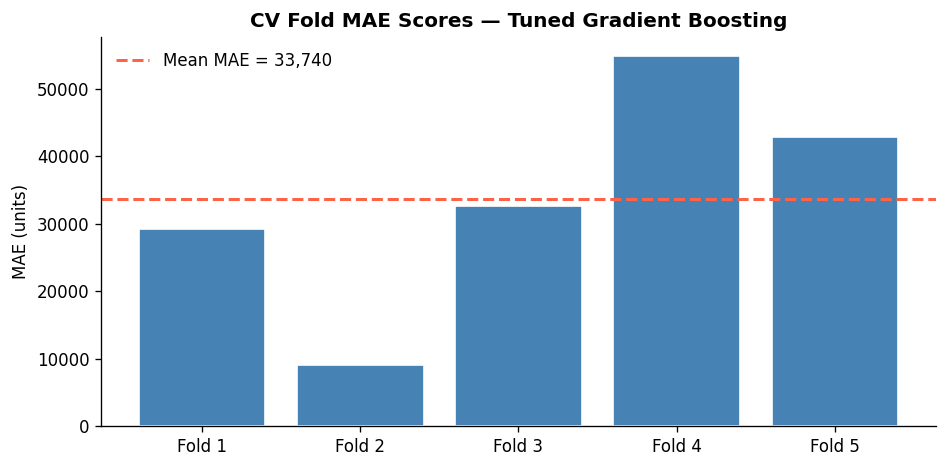

In [28]:
# ── Evaluate tuned model on test set ──────────────────────────────────────
best_pipe  = search.best_estimator_
tuned_pred = best_pipe.predict(X_test)

tuned_mae  = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2   = r2_score(y_test, tuned_pred)
tuned_mape = np.mean(np.abs((y_test - tuned_pred) / y_test)) * 100

print("=== Tuned GBM Test-Set Performance ===")
print(f"  R²   : {tuned_r2:.4f}")
print(f"  MAE  : {tuned_mae:,.0f}")
print(f"  RMSE : {tuned_rmse:,.0f}")
print(f"  MAPE : {tuned_mape:.2f}%")

# CV fold scores
cv_results = pd.DataFrame(search.cv_results_)
best_idx   = search.best_index_
fold_scores = [-cv_results[f'split{i}_test_score'][best_idx] for i in range(5)]

plt.figure(figsize=(8, 4))
bars = plt.bar([f'Fold {i+1}' for i in range(5)], fold_scores,
               color='steelblue', edgecolor='white')
plt.axhline(np.mean(fold_scores), color='tomato', linewidth=1.8,
            linestyle='--', label=f'Mean MAE = {np.mean(fold_scores):,.0f}')
plt.title('CV Fold MAE Scores — Tuned Gradient Boosting', fontsize=12, fontweight='bold')
plt.ylabel('MAE (units)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


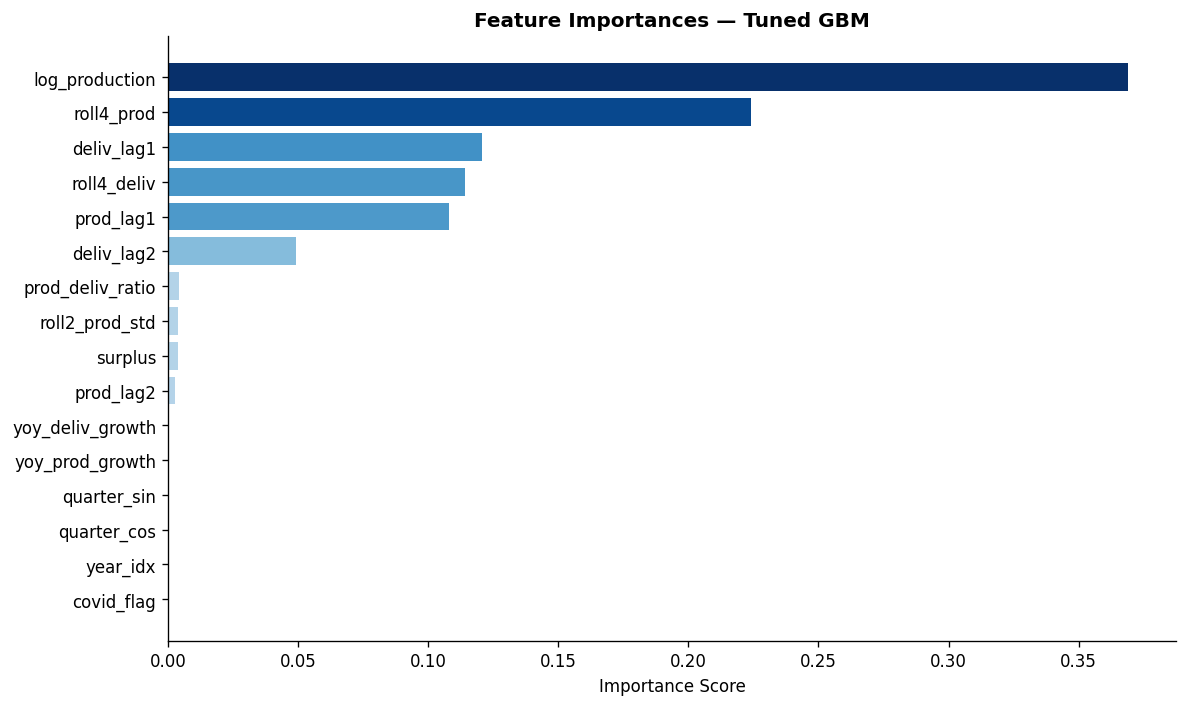

In [29]:
# ── Feature importance of tuned model ─────────────────────────────────────
gbm_model = best_pipe.named_steps['model']
importances = pd.Series(gbm_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances.index, importances.values,
                color=plt.cm.Blues(importances.values / importances.values.max() + 0.3))
plt.title('Feature Importances — Tuned GBM', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 8. Time Series Forecasting

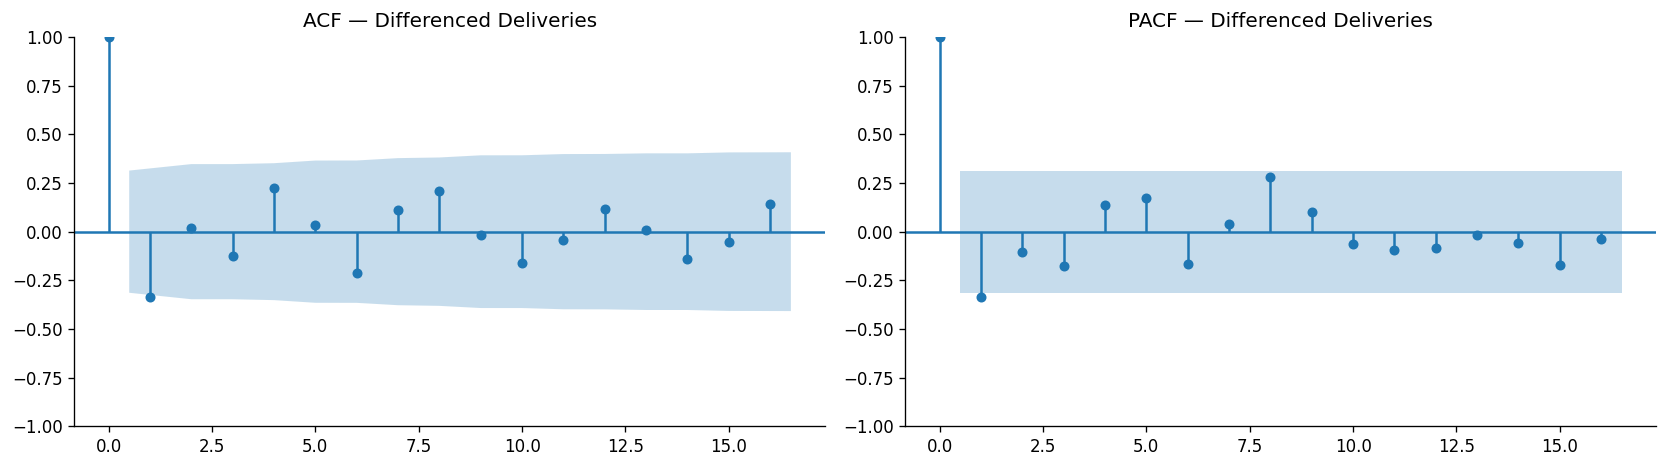

In [30]:
# ── ACF / PACF plots to guide SARIMA order selection ──────────────────────
deliv_diff = df['deliveries'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(deliv_diff,  lags=16, ax=axes[0], title='ACF — Differenced Deliveries')
plot_pacf(deliv_diff, lags=16, ax=axes[1], title='PACF — Differenced Deliveries', method='ywm')
plt.tight_layout()
plt.show()


In [31]:
# ── Define training series and forecast horizon ───────────────────────────
train_ts = df['deliveries']
H = 8   # quarters to forecast

In [32]:
# ── SARIMA(1,1,1)(1,1,1)[4] ───────────────────────────────────────────────

sarima = SARIMAX(train_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 4),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        deliveries   No. Observations:                   40
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -348.356
Date:                           Sun, 28 Jun 2026   AIC                            706.711
Time:                                   10:34:56   BIC                            713.548
Sample:                               01-01-2015   HQIC                           708.852
                                    - 10-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5057      0.659     -0.767      0.443      -1.798       0.787
ma.L1          0.1670      0.667      0.250

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [33]:
# The forecasting variable definitions and table printing code were moved to the plotting cell (46241e23) to ensure variables are defined before use.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)



=== 8-Quarter Delivery Forecast ===
         SARIMA  Holt-Winters  Ensemble  Lower 95%  Upper 95%
2025-Q1     NaN           NaN       NaN        NaN        NaN
2025-Q2     NaN           NaN       NaN        NaN        NaN
2025-Q3     NaN           NaN       NaN        NaN        NaN
2025-Q4     NaN           NaN       NaN        NaN        NaN
2026-Q1     NaN           NaN       NaN        NaN        NaN
2026-Q2     NaN           NaN       NaN        NaN        NaN
2026-Q3     NaN           NaN       NaN        NaN        NaN
2026-Q4     NaN           NaN       NaN        NaN        NaN


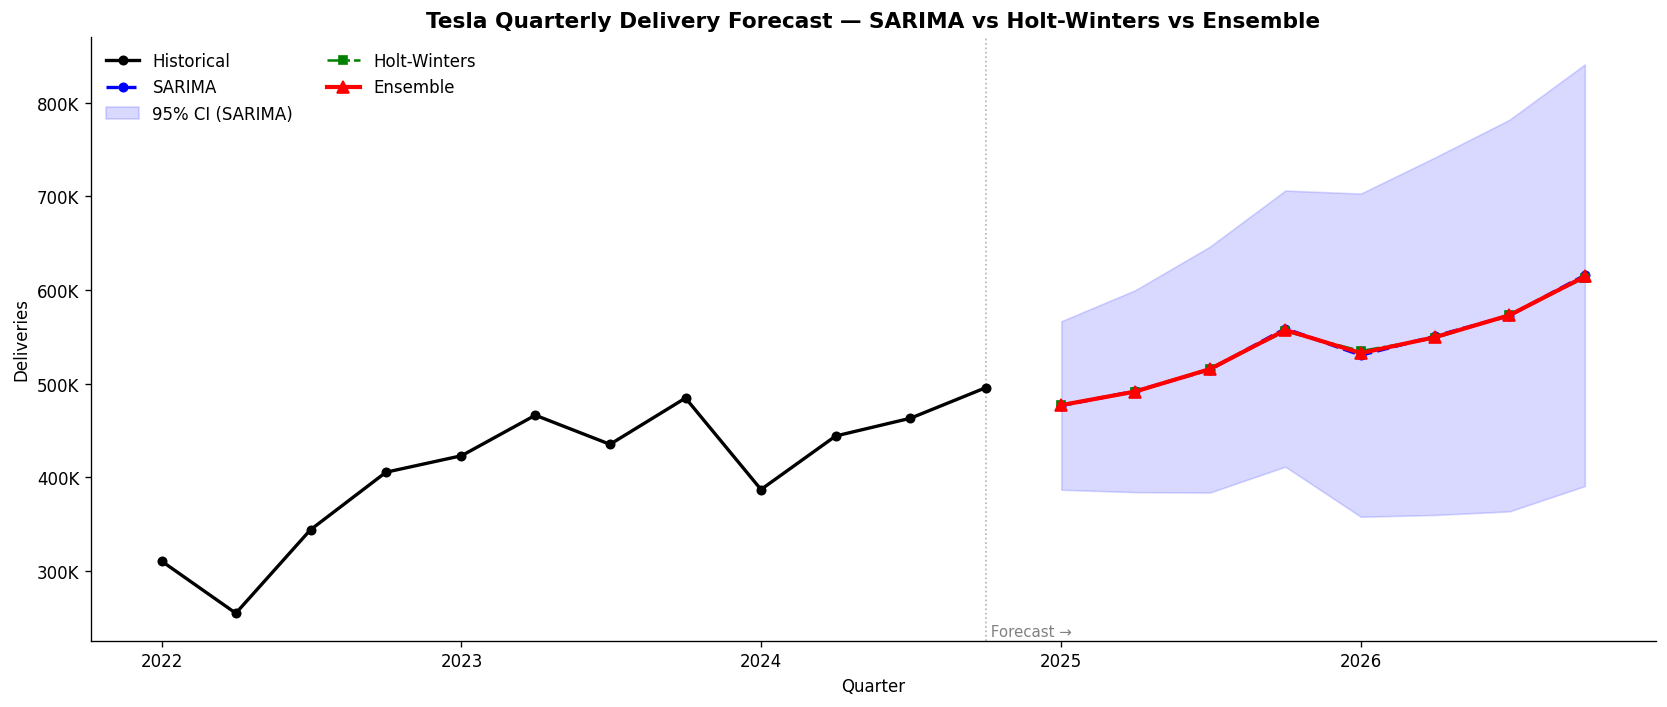

In [34]:
# ── Holt-Winters ──────────────────────────────────────────────────────────
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                                 seasonal_periods=4).fit(optimized=True)

# ── Forecasts ─────────────────────────────────────────────────────────────
sarima_fc = sarima_fit.get_forecast(steps=H)
sarima_mean = sarima_fc.predicted_mean
sarima_ci   = sarima_fc.conf_int(alpha=0.05)

hw_fc = hw_model.forecast(H)

# Forecast dates (quarterly)
last_date  = df.index[-1]
fc_idx = pd.date_range(last_date + pd.DateOffset(months=3), periods=H, freq='QS')
sarima_mean.index = fc_idx
sarima_ci.index   = fc_idx
hw_fc.index       = fc_idx

# Ensemble
ensemble_fc = (sarima_mean + hw_fc) / 2

print("\n=== 8-Quarter Delivery Forecast ===")
fc_table = pd.DataFrame({
    'SARIMA':       sarima_mean.round(0),
    'Holt-Winters': hw_fc.round(0),
    'Ensemble':     ensemble_fc.round(0),
    'Lower 95%':    sarima_ci.iloc[:, 0].round(0),
    'Upper 95%':    sarima_ci.iloc[:, 1].round(0),
}, index=[d.strftime('%Y-Q%q' if hasattr(d,'quarter') else str(d)) for d in fc_idx])
fc_table.index = [f'{d.year}-Q{(d.month-1)//3+1}' for d in fc_idx]
print(fc_table.to_string())

# ── Forecast visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# History (last 3 years)
hist = df['deliveries']['2022':]
ax.plot(hist.index, hist.values, 'k-o', linewidth=2, markersize=5, label='Historical', zorder=5)

# SARIMA
ax.plot(fc_idx, sarima_mean.values, 'b--o', linewidth=2, markersize=5, label='SARIMA')
ax.fill_between(fc_idx,
                sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                alpha=0.15, color='blue', label='95% CI (SARIMA)')

# Holt-Winters
ax.plot(fc_idx, hw_fc.values, 'g-.s', linewidth=1.5, markersize=5, label='Holt-Winters')

# Ensemble
ax.plot(fc_idx, ensemble_fc.values, 'r-^', linewidth=2.5, markersize=7, label='Ensemble', zorder=4)

# Divider
ax.axvline(df.index[-1], color='gray', linewidth=1, linestyle=':', alpha=0.6)
ax.text(df.index[-1], ax.get_ylim()[0]*1.02, ' Forecast →', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Tesla Quarterly Delivery Forecast — SARIMA vs Holt-Winters vs Ensemble',
             fontsize=13, fontweight='bold')
ax.legend(frameon=False, ncol=2)
ax.set_xlabel('Quarter')
ax.set_ylabel('Deliveries')
plt.tight_layout()
plt.show()

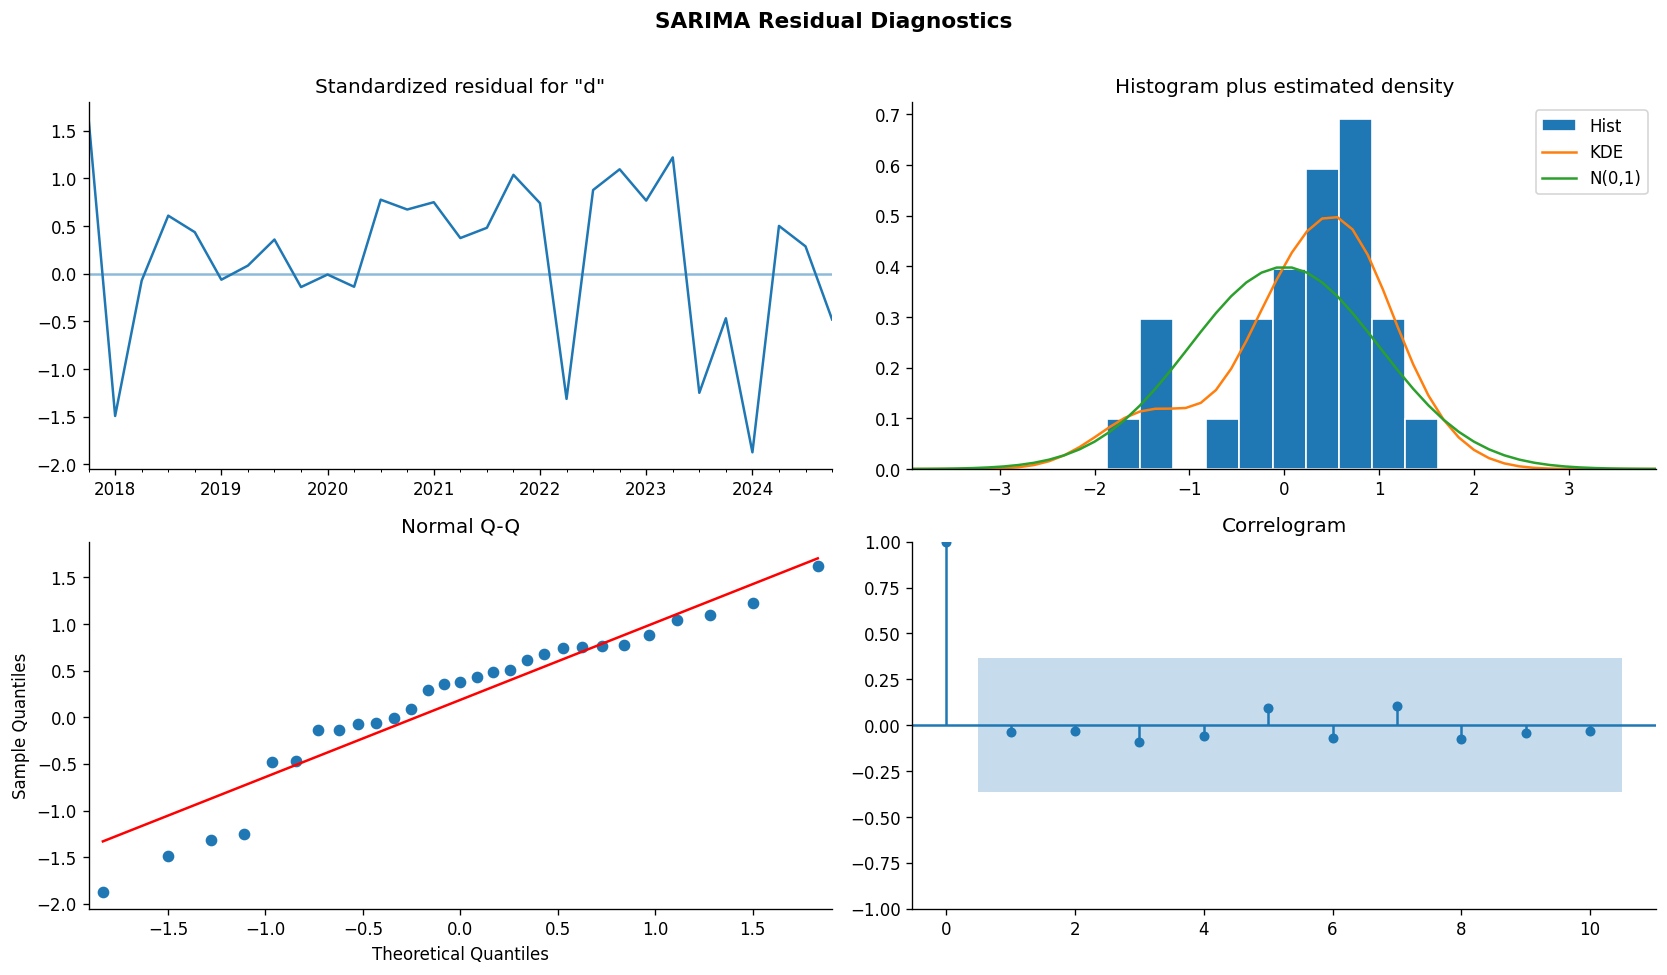

In [35]:
# ── SARIMA residual diagnostics ───────────────────────────────────────────
sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Pipeline Summary & Key Findings

In [43]:
print("=" * 60)
print("  TESLA ML PIPELINE — SUMMARY REPORT")
print("=" * 60)

print("\n📊 DATASET")
print(f"   Quarters : {len(df)}")
print(f"   Range    : {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Features : {len(FEATURES)}")

print("\n🔍 EDA INSIGHTS")
annual_del = df.groupby('year')['deliveries'].sum()
cagr = (annual_del.iloc[-1] / annual_del.iloc[0]) ** (1/(len(annual_del)-1)) - 1
print(f"   Cumulative deliveries (2015-2024): {df['deliveries'].sum()/1e6:.2f}M")
print(f"   Delivery CAGR (2015–2024): {cagr*100:.1f}%")
print(f"   Peak quarter: {df['deliveries'].idxmax().strftime('%Y-Q')+str((df['deliveries'].idxmax().month-1)//3+1)} "
      f"({df['deliveries'].max()/1e3:.0f}K units)")

print("\n🤖 BEST REGRESSION MODEL")
best_name = results_df['R2'].idxmax()
print(f"   Model  : {best_name}")
print(f"   R²     : {tuned_r2:.4f}")
print(f"   MAE    : {tuned_mae:,.0f} units")
print(f"   MAPE   : {tuned_mape:.2f}%")

print("\n📈 FORECASTS (next 4 quarters)")
for dt, val in list(zip(fc_idx, ensemble_fc.values))[:4]:
    qtr = f"{dt.year}-Q{(dt.month-1)//3+1}"
    print(f"   {qtr}: {val:,.0f} units")

print("\n✅ Pipeline complete!")

  TESLA ML PIPELINE — SUMMARY REPORT

📊 DATASET
   Quarters : 40
   Range    : 2015-01-01 → 2024-10-01
   Features : 16

🔍 EDA INSIGHTS
   Cumulative deliveries (2015-2024): 7.18M
   Delivery CAGR (2015–2024): 56.4%
   Peak quarter: 2024-Q4 (496K units)

🤖 BEST REGRESSION MODEL
   Model  : Ridge Regression
   R²     : -3.4184
   MAE    : 61,803 units
   MAPE   : 13.30%

📈 FORECASTS (next 4 quarters)
   2025-Q1: 476,952 units
   2025-Q2: 491,410 units
   2025-Q3: 515,366 units
   2025-Q4: 557,138 units

✅ Pipeline complete!
